### Workflow

https://github.com/geosensing/geo_sampling/blob/public/docs/workflow.rst

In [1]:
#%pip install allocator
#%pip install geo_sampling

#import geo_sampling
#import allocator
import shapefile
import pandas as pd
import random
import numpy as np

from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt

In [3]:
# Load the shapefile (both .shp and .dbf should be in the same directory)
shp_path = "../data/gadm41_IND_2.shp"  # Update path if needed
sf = shapefile.Reader(shp_path)

# Extract the fields and records
fields = [field[0] for field in sf.fields[1:]]  # Ignore first field ('DeletionFlag')
records = sf.records()

# Find the index of the "NAME_2" field (which contains "Mumbai City")
name_index = fields.index("NAME_2")  

# Extract polylines for "NCT of Delhi"
delhi_shapes = [shape for record, shape in zip(records, sf.shapes()) if record[name_index] == "Navi Mumbai"]

# Get bounding box (min_x, min_y, max_x, max_y)
all_points = [point for shape in delhi_shapes for point in shape.points]
min_x = min(p[0] for p in all_points)
min_y = min(p[1] for p in all_points)
max_x = max(p[0] for p in all_points)
max_y = max(p[1] for p in all_points)

ValueError: min() arg is an empty sequence

In [4]:
import osmnx as ox
import geopandas as gpd
import matplotlib.pyplot as plt
import random
from shapely.geometry import Point

# Approximate bounding box for Navi Mumbai
north, south, east, west = 19.2, 18.9, 73.1, 72.9

# Get the street network for this area
G = ox.graph_from_bbox(north, south, east, west, network_type='all')

# Convert to GeoDataFrames
nodes, edges = ox.graph_to_gdfs(G)

# Plot to verify
fig, ax = plt.subplots(figsize=(12, 10))
edges.plot(ax=ax, linewidth=0.5, color='gray')
ax.set_title("Navi Mumbai Street Network")
plt.tight_layout()
plt.show()

# Save if needed
edges.to_file("navi_mumbai_streets.geojson", driver="GeoJSON")

ModuleNotFoundError: No module named 'osmnx'

In [3]:
# Construct BBBike extract URL
bbbike_url = f"http://extract.bbbike.org/?sw_lng={min_x}&sw_lat={min_y}&ne_lng={max_x}&ne_lat={max_y}"
print("BBBike Extract URL:", bbbike_url)

BBBike Extract URL: http://extract.bbbike.org/?sw_lng=72.79152679500004&sw_lat=18.890695572000084&ne_lng=72.88465118300002&ne_lat=19.05473518399998


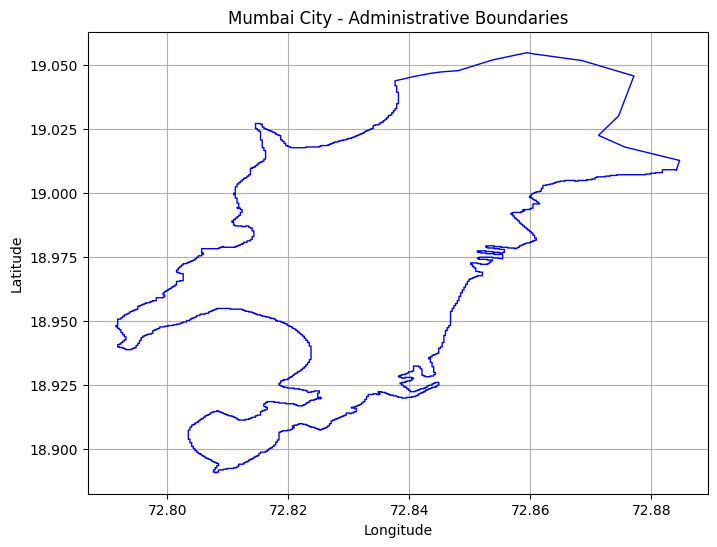

In [4]:
# Plot Delhi map
plt.figure(figsize=(8, 6))
for shape in delhi_shapes:
    x, y = zip(*shape.points)  # Extract x and y coordinates
    plt.plot(x, y, 'b', linewidth=1)

plt.title("Mumbai City - Administrative Boundaries")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()

In [5]:
# Load the roads shapefile
roads_shp_path = "../data/IND_IND.20_1+Mumbai City_roads.shp"  # Update path if needed
sf = shapefile.Reader(roads_shp_path)

# Extract fields and records
fields = [field[0] for field in sf.fields[1:]]  # Skip first field ('DeletionFlag')
records = sf.records()

# Inspect field names to find relevant ones
print("Fields in shapefile:", fields)

Fields in shapefile: ['osm_id', 'name', 'ref', 'type', 'oneway', 'bridge', 'maxspeed']


In [6]:
# Assume "road_type" or similar field exists; update this based on inspection
road_type_field = "type"  # Update if needed
road_type_index = fields.index(road_type_field)

unique_road_types = set(record[road_type_index] for record in sf.records())
print("Unique road types in shapefile:", unique_road_types)

Unique road types in shapefile: {'pedestrian', 'steps', 'tertiary', 'tertiary_link', 'primary_link', 'secondary', 'construction', 'proposed', 'path', 'motorway', 'primary', 'services', 'trunk', 'secondary_link', 'living_street', 'motorway_link', 'residential', 'track', 'footway', 'service', 'unclassified', 'trunk_link'}


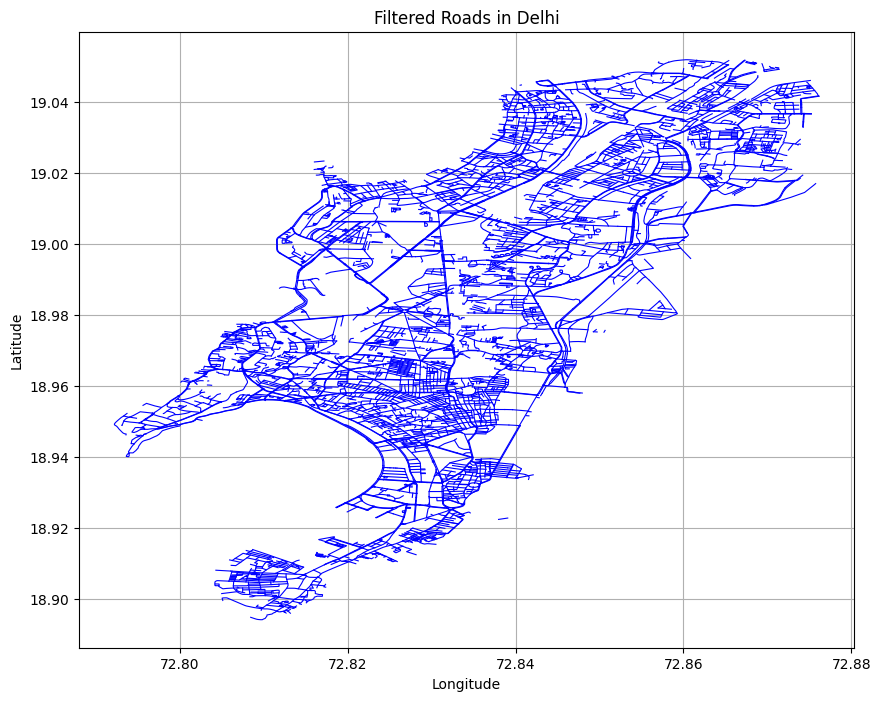

In [7]:
# Define road types to filter (e.g., "highway", "main road", "primary road")
road_types_of_interest = ["residential", "primary", "secondary", "tertiary"]

# Extract roads of interest
selected_roads = [shape for record, shape in zip(records, sf.shapes()) if record[road_type_index] in road_types_of_interest]
#selected_roads = [shape for record, shape in zip(records, sf.shapes())]

# Plot the selected roads
plt.figure(figsize=(10, 8))

for shape in selected_roads:
    x, y = zip(*shape.points)  # Extract coordinates
    plt.plot(x, y, 'b', linewidth=0.8)  # Plot with blue color

plt.title("Filtered Roads in Delhi")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()

In [8]:
# Extract field names
fields = [field[0] for field in sf.fields[1:]]  # Ignore DeletionFlag
print("Fields:", fields)  # Identify road type field

# Extract road data into a DataFrame
road_data = []
#for record, shape in zip(sf.records(), sf.shapes()):
for record, shape in zip(sf.records(), sf.shapes()):
    if record[road_type_index] not in road_types_of_interest:
        continue
    if shape.shapeType == 3:  # Ensure it's a polyline
        start_lat, start_long = shape.points[0]
        end_lat, end_long = shape.points[-1]
        road_data.append(list(record) + [start_lat, start_long, end_lat, end_long])

# Create DataFrame
df_roads = pd.DataFrame(road_data, columns=fields + ["start_lat", "start_long", "end_lat", "end_long"])

# Display sample
df_roads.head()

Fields: ['osm_id', 'name', 'ref', 'type', 'oneway', 'bridge', 'maxspeed']


,osm_id,name,ref,type,oneway,bridge,maxspeed,start_lat,start_long,end_lat,end_long
0,22845315,Badaruddin Tayabji Marg,,tertiary,0,0,NaN,72.830680,18.942550,72.832707,18.944611
1,22845318,Homi Modi Street,,residential,1,0,NaN,72.831716,18.931634,72.834059,18.931166
2,22845331,Jeejeebhoy Dadabhoy Lane,,residential,0,0,NaN,72.835407,18.936243,72.833872,18.936409
3,22845332,Kumtha Street,,residential,0,0,NaN,72.840520,18.935936,72.839395,18.936174
4,22845343,Viju Kotak Marg,,residential,0,0,NaN,72.839039,18.936844,72.836951,18.937318


In [9]:
df_roads.columns

Index(['osm_id', 'name', 'ref', 'type', 'oneway', 'bridge', 'maxspeed',
       'start_lat', 'start_long', 'end_lat', 'end_long'],
      dtype='object')

In [10]:
# Let's chunk with Haversine

def haversine(lat1, lon1, lat2, lon2):
    """Compute the Haversine distance (in meters) between two lat/lon points."""
    R = 6371000  # Earth's radius in meters
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    delta_phi = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)
    
    a = np.sin(delta_phi / 2.0)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda / 2.0)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    
    return R * c  # Distance in meters

In [11]:
# Compute road segment length in meters
df_roads["LENGTH_M"] = df_roads.apply(
    lambda row: haversine(row["start_lat"], row["start_long"], row["end_lat"], row["end_long"]),
    axis=1
)

# Check length distribution
print(df_roads["LENGTH_M"].describe())

count    5517.000000
mean      100.406768
std       125.092815
min         0.000000
25%        21.600474
50%        56.868614
75%       131.441317
max      1421.835564
Name: LENGTH_M, dtype: float64


In [12]:
def split_road_segment(row, segment_length=500):
    """Splits a road segment into equal chunks of segment_length (in meters)."""
    road_length = row["LENGTH_M"]
    
    if road_length <= segment_length:
        return [row.to_dict()]  # Return original row as a list to avoid NaNs

    num_segments = int(np.ceil(road_length / segment_length))  # Number of 500m chunks

    start_lat, start_long = row["start_lat"], row["start_long"]
    end_lat, end_long = row["end_lat"], row["end_long"]

    lat_step = (end_lat - start_lat) / num_segments
    long_step = (end_long - start_long) / num_segments

    split_segments = []
    for i in range(num_segments):
        new_start_lat = start_lat + (i * lat_step)
        new_start_long = start_long + (i * long_step)
        new_end_lat = new_start_lat + lat_step
        new_end_long = new_start_long + long_step

        new_segment = row.to_dict()
        new_segment["start_lat"] = new_start_lat
        new_segment["start_long"] = new_start_long
        new_segment["end_lat"] = new_end_lat
        new_segment["end_long"] = new_end_long
        new_segment["SEGMENT_PART"] = i + 1
        new_segment["LENGTH_M"] = segment_length  # Set length to 500m

        split_segments.append(new_segment)

    return split_segments

In [13]:
df_long_roads = df_roads[df_roads["LENGTH_M"] > 500]
df_short_roads = df_roads[df_roads["LENGTH_M"] <= 500]

# Apply fixed chunking function
df_long_roads_split = df_long_roads.apply(split_road_segment, axis=1)

# Ensure list format before explode()
df_long_roads_split = df_long_roads_split.explode().reset_index(drop=True)

# Convert dictionaries back to DataFrame
df_long_roads_split = pd.DataFrame(list(df_long_roads_split))

# Combine back
df_roads_final = pd.concat([df_short_roads, df_long_roads_split], ignore_index=True)

print("✅ Roads successfully chunked into 500m segments!")

✅ Roads successfully chunked into 500m segments!


In [14]:
# Randomly sample 1000 roads
df_sampled = df_roads_final.sample(n=1000, random_state=42)  # Change `n` if needed

df_sampled.head()

,osm_id,name,ref,type,oneway,bridge,maxspeed,start_lat,start_long,end_lat,end_long,LENGTH_M,SEGMENT_PART
3494,1139162523,Dr Madhukar B. Raut Marg,,residential,0,0,NaN,72.839785,19.025565,72.839848,19.025635,7.354409,NaN
1609,214699887,,,residential,0,0,NaN,72.811603,18.906561,72.809711,18.906770,210.426626,NaN
1097,42879186,Nathalal M Parekh Marg,,residential,1,0,NaN,72.855848,19.026484,72.856934,19.025663,123.768756,NaN
2302,658655413,Dr Annie Besant Road,,primary,1,0,NaN,72.813966,18.990332,72.814015,18.990626,11.087055,NaN
4500,1235771381,Flank Road,,tertiary,0,0,NaN,72.865169,19.037447,72.867013,19.039603,216.900199,NaN


In [15]:
# Let's sort segments by distance

# Extract lat/lon from the sampled dataset
coords = df_sampled[['start_lat', 'start_long']].to_numpy()

import math
import requests
MAX_DISTANCE_MATRIX_SIZE = 100

def osrm_distance_matrix(X, Y=None, chunksize=MAX_DISTANCE_MATRIX_SIZE):
    """
    Calculate distance matrix of arbitrary size using OSRM

    Credits: https://github.com/stepankuzmin/distance-matrix

    Please note that OSRM distance matrix is in duration in seconds.

    """
    # FIXME: by Car - driving, Bike - bicycle, Walking - foot
    # but I don't see the different
    api_base = 'http://router.project-osrm.org/table/v1/bicycle/'

    n_X = len(X)
    if Y is None:
        Y = X
    n_Y = len(Y)
    m = chunksize * 1.0
    Xsplits = math.ceil(n_X / m)
    Ysplits = math.ceil(n_Y / m)
    o = None
    count = 0
    for s in np.array_split(X, Xsplits):
        c = None
        for d in np.array_split(Y, Ysplits):
            a = ';'.join([','.join([str(x) for x in b]) for b in (list(s) +
                                                                  list(d))])
            sources = ';'.join([str(k) for k in range(0, len(s))])
            destinations = ';'.join([str(k) for k in range(len(s), len(s) +
                                                           len(d))])
            # FIXME: both distance and duration
            url = (api_base + a + '?annotations=distance,duration&sources=' + sources +
                   '&destinations=' + destinations)
            count += 1
            r = requests.get(url)
            if r.status_code != 200:
                print(("OSRM Table API request error: {0:s}".format(r.text)))
                break
            # FIXME: Change to distance.
            #dm = r.json()['durations']
            dm = r.json()['distances']
            arr = np.array(dm)
            if c is None:
                c = arr
            else:
                c = np.concatenate((c, arr), axis=1)
        if o is None:
            o = c
        else:
            o = np.concatenate((o, c), axis=0)
        print(f"Current OSRM API requests count: {count}")
    print(("Total API requests: {0:d}".format(count)))
    return o

# Compute pairwise Haversine distances
def haversine_distance_matrix(coords):
    """Compute distance matrix using the Haversine formula."""
    def haversine(p1, p2):
        R = 6371000  # Earth's radius in meters
        lat1, lon1, lat2, lon2 = np.radians([p1[0], p1[1], p2[0], p2[1]])
        dlat, dlon = lat2 - lat1, lon2 - lon1
        a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
        return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return squareform(pdist(coords, metric=haversine))

# Compute distance matrix
#distance_matrix = haversine_distance_matrix(coords)
distance_matrix = osrm_distance_matrix(coords)

Current OSRM API requests count: 10
Current OSRM API requests count: 20
Current OSRM API requests count: 30
Current OSRM API requests count: 40
Current OSRM API requests count: 50
Current OSRM API requests count: 60
Current OSRM API requests count: 70
Current OSRM API requests count: 80
Current OSRM API requests count: 90
Current OSRM API requests count: 100
Total API requests: 100


In [16]:
from scipy.spatial import distance

def nearest_neighbor_sort(distance_matrix):
    """Sort indices by nearest neighbor heuristic."""
    n = len(distance_matrix)
    visited = np.zeros(n, dtype=bool)
    sorted_indices = [0]  # Start from the first segment
    visited[0] = True

    for _ in range(1, n):
        last_index = sorted_indices[-1]
        remaining_indices = np.where(~visited)[0]  # Unvisited points
        nearest_index = remaining_indices[np.argmin(distance_matrix[last_index, remaining_indices])]
        sorted_indices.append(nearest_index)
        visited[nearest_index] = True

    return sorted_indices

# Get sorting order
sorted_order = nearest_neighbor_sort(distance_matrix)

# Reorder DataFrame
df_sorted = df_sampled.iloc[sorted_order].reset_index(drop=True)

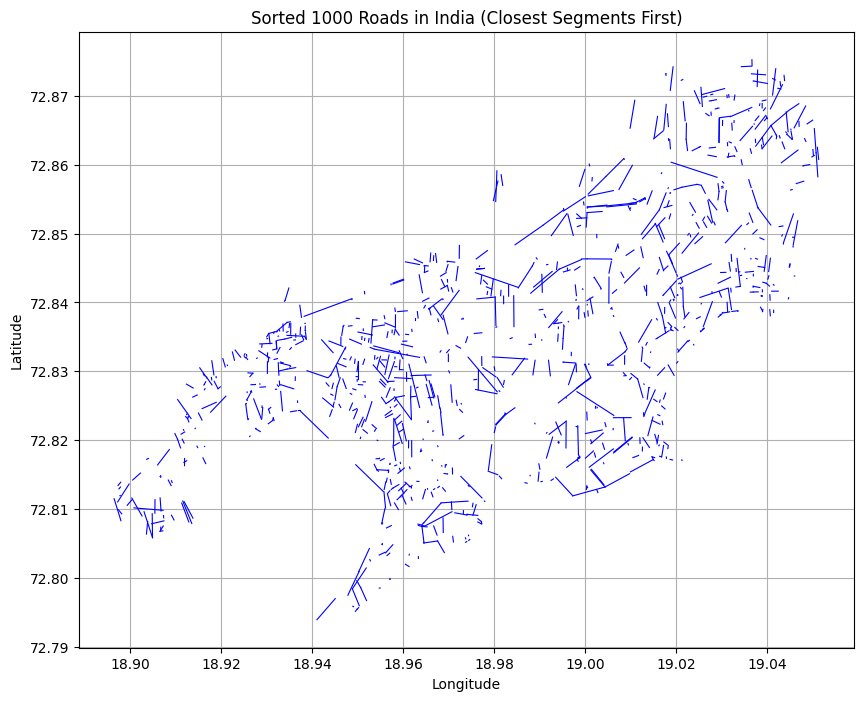

In [17]:
plt.figure(figsize=(10, 8))

for _, row in df_sorted.iterrows():
    x = [row["start_long"], row["end_long"]]
    y = [row["start_lat"], row["end_lat"]]
    plt.plot(x, y, 'b', linewidth=0.8)

plt.title("Sorted 1000 Roads in India (Closest Segments First)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()

In [18]:
df_distance_matrix = pd.DataFrame(distance_matrix, columns=df_sampled.osm_id, index=df_sampled.osm_id)
df_distance_matrix

osm_id,1139162523,214699887,42879186,658655413,1235771381,647578138,438742487,786424538,214699931,1139122583,...,1188785944,1177464841,22845484,22851562,22851166,1303402799,1081145893,22848175,1329316284,1138592091
osm_id,,,,,,,,,,,,,,,,,,,,,
1139162523,0.0,15645.9,2729.2,6196.5,4334.6,12190.4,10514.1,11127.7,16394.1,1098.8,...,1597.2,8627.2,10966.1,5035.4,9501.5,5001.1,10300.3,2704.9,5230.3,8977.7
214699887,15425.4,0.0,15641.5,11559.6,17246.9,3340.7,5601.7,5187.1,1209.8,15165.4,...,16877.0,7301.6,5247.8,11320.6,6285.8,17770.1,7360.3,13412.5,18021.5,8568.9
42879186,2751.7,15589.1,0.0,7882.6,2003.6,12133.6,10457.3,11070.8,16337.3,2491.8,...,4203.4,8570.4,10909.2,5002.2,9444.6,3376.1,10243.5,2671.7,2899.4,10894.8
658655413,5685.6,13369.5,7403.8,0.0,9009.2,10643.3,7547.1,9088.0,14382.6,4988.7,...,6838.1,5471.8,8926.4,6683.8,6756.2,9675.7,4938.3,5533.6,9904.9,4234.7
1235771381,4523.5,17360.8,1771.7,9654.3,0.0,13905.3,12229.0,12842.6,18109.0,4263.5,...,3572.0,10342.1,12681.0,6302.1,11216.4,2203.8,12015.2,4443.4,1160.5,12666.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1303402799,5193.4,17633.9,3132.7,10347.9,2190.4,14516.2,12922.6,13453.5,18382.0,4933.5,...,6645.1,11035.7,13052.7,5109.5,11905.9,0.0,12708.8,4286.0,1466.9,13360.2
1081145893,10411.0,7304.7,10627.1,4227.1,12232.5,4578.5,3333.5,4294.7,8317.8,9041.3,...,11862.6,1963.8,4133.1,8035.1,3519.5,13710.2,0.0,8398.1,13961.5,1236.3
22848175,2784.6,13581.4,3000.7,6232.6,4606.1,10125.9,8449.6,9063.2,14329.6,2524.7,...,4236.3,6562.7,8901.6,3158.8,7437.0,4186.3,8235.8,0.0,4437.6,8887.2


In [19]:
# FIXME: Drop duplicated entry
df_sorted.drop_duplicates(subset=['osm_id'], keep='first', inplace=True)
df_sorted.reset_index(drop=True, inplace=True)
df_sorted

,osm_id,name,ref,type,oneway,bridge,maxspeed,start_lat,start_long,end_lat,end_long,LENGTH_M,SEGMENT_PART
0,1139162523,Dr Madhukar B. Raut Marg,,residential,0,0,NaN,72.839785,19.025565,72.839848,19.025635,7.354409,NaN
1,113715151,Shivaji Park Road no.1,,residential,0,0,NaN,72.837647,19.024550,72.837912,19.025375,39.996461,NaN
2,1139286217,Ranade Road,,tertiary,0,0,NaN,72.835858,19.025413,72.835763,19.025464,10.726683,NaN
3,1139286213,Swatantrya Veer Savarkar Marg,,secondary,1,0,NaN,72.835763,19.025464,72.836203,19.026239,55.205796,NaN
4,1139162520,Swatantrya Veer Savarkar Marg,,secondary,1,0,NaN,72.836280,19.026198,72.836092,19.025848,23.804443,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
990,941304835,,,residential,0,0,NaN,72.829371,19.009031,72.829793,19.008469,50.494185,NaN
991,1303403584,Lala Lajpatrai Marg,,primary,1,0,NaN,72.813817,18.986815,72.813745,18.987302,17.895095,NaN
992,212159148,,,residential,0,0,NaN,72.854788,18.979875,72.857627,18.980864,317.430897,NaN
993,22851503,Signal Hill Avenue,,tertiary,0,0,NaN,72.854654,18.980384,72.859120,18.980647,500.000000,2.0


In [20]:
# Compute distances for consecutive locations
distances = []
for i in range(len(df_sorted) - 1):
    loc1 = df_sorted.loc[i, 'osm_id']
    loc2 = df_sorted.loc[i + 1, 'osm_id']
    distance = df_distance_matrix.loc[loc1, loc2]
    # FIXME: choose first one if there is dumplicate osm_id in distance matrix
    while not isinstance(distance, float):
        distance = distance.iloc[0]
    distances.append(distance)

# Add distances to a new column
df_sorted['osrm_travel_distance'] = [None] + distances  # Add None for first row

df_sorted

,osm_id,name,ref,type,oneway,bridge,maxspeed,start_lat,start_long,end_lat,end_long,LENGTH_M,SEGMENT_PART,osrm_travel_distance
0,1139162523,Dr Madhukar B. Raut Marg,,residential,0,0,NaN,72.839785,19.025565,72.839848,19.025635,7.354409,NaN,NaN
1,113715151,Shivaji Park Road no.1,,residential,0,0,NaN,72.837647,19.024550,72.837912,19.025375,39.996461,NaN,286.3
2,1139286217,Ranade Road,,tertiary,0,0,NaN,72.835858,19.025413,72.835763,19.025464,10.726683,NaN,282.2
3,1139286213,Swatantrya Veer Savarkar Marg,,secondary,1,0,NaN,72.835763,19.025464,72.836203,19.026239,55.205796,NaN,11.5
4,1139162520,Swatantrya Veer Savarkar Marg,,secondary,1,0,NaN,72.836280,19.026198,72.836092,19.025848,23.804443,NaN,106.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
990,941304835,,,residential,0,0,NaN,72.829371,19.009031,72.829793,19.008469,50.494185,NaN,58.3
991,1303403584,Lala Lajpatrai Marg,,primary,1,0,NaN,72.813817,18.986815,72.813745,18.987302,17.895095,NaN,6762.9
992,212159148,,,residential,0,0,NaN,72.854788,18.979875,72.857627,18.980864,317.430897,NaN,7849.4
993,22851503,Signal Hill Avenue,,tertiary,0,0,NaN,72.854654,18.980384,72.859120,18.980647,500.000000,2.0,51.9


In [21]:
MAX_ITINERARY_DISTANCE = 20000  # 20 km in meters

itineraries = []
current_itinerary = []
current_distance = 0
itinerary_id = 1

for i, row in df_sorted.iterrows():
    segment_length = row["LENGTH_M"]
    travel_distance = row["osrm_travel_distance"] if i > 0 else 0  # No travel for the first segment

    if current_distance + segment_length + travel_distance > MAX_ITINERARY_DISTANCE:
        itineraries.append({"itinerary_id": itinerary_id, "segments": current_itinerary})
        current_itinerary = []
        current_distance = 0
        itinerary_id += 1

    current_itinerary.append(row.to_dict())
    current_distance += segment_length + travel_distance

# Add the last itinerary
if current_itinerary:
    itineraries.append({"itinerary_id": itinerary_id, "segments": current_itinerary})

print(f"✅ Created {len(itineraries)} itineraries.")

✅ Created 27 itineraries.


In [22]:
# Flatten the itineraries
flat_data = []
for itinerary in itineraries:
    itinerary_id = itinerary["itinerary_id"]
    for segment in itinerary["segments"]:
        segment["itinerary_id"] = itinerary_id
        flat_data.append(segment)

# Convert to DataFrame
df_itineraries = pd.DataFrame(flat_data)

# Save to CSV
df_itineraries.to_csv("../out/itineraries-mumbai-city-osrm.csv", index=False)
print("✅ Saved itineraries to 'itineraries-mumbai-city-osrm.csv'.")

✅ Saved itineraries to 'itineraries-mumbai-city-osrm.csv'.


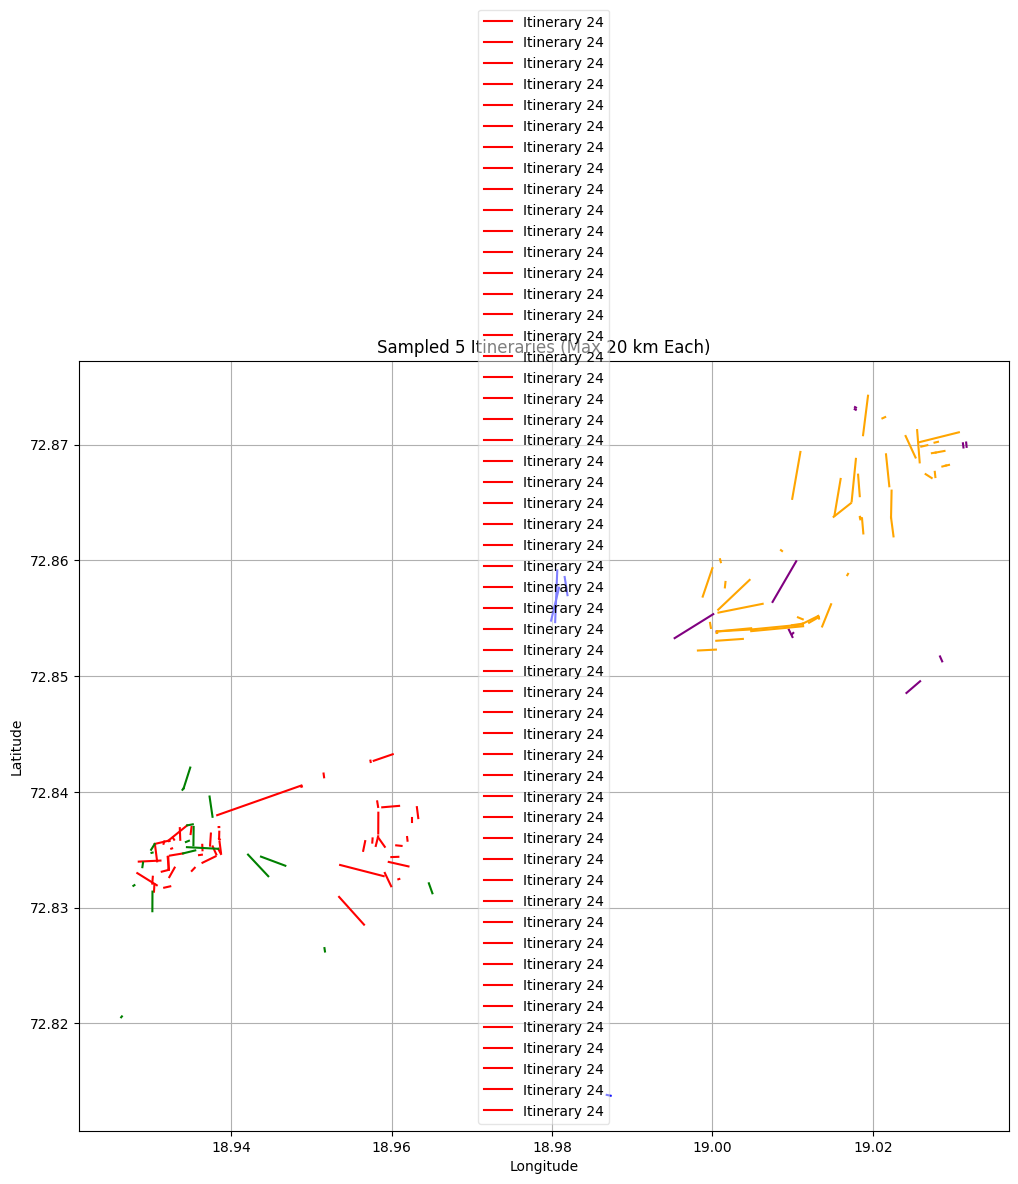

In [23]:
# Select 5 random itineraries
sample_itineraries = random.sample(df_itineraries["itinerary_id"].unique().tolist(), 5)
colors = ["red", "blue", "green", "purple", "orange"]

plt.figure(figsize=(12, 10))

for i, itinerary_id in enumerate(sample_itineraries):
    df_subset = df_itineraries[df_itineraries["itinerary_id"] == itinerary_id]

    for _, row in df_subset.iterrows():
        x = [row["start_long"], row["end_long"]]
        y = [row["start_lat"], row["end_lat"]]
        plt.plot(x, y, color=colors[i], linewidth=1.5, label=f"Itinerary {itinerary_id}" if i == 0 else "")

plt.title("Sampled 5 Itineraries (Max 20 km Each)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(loc="best", fancybox=True, framealpha=0.5)
plt.grid(True)
plt.show()

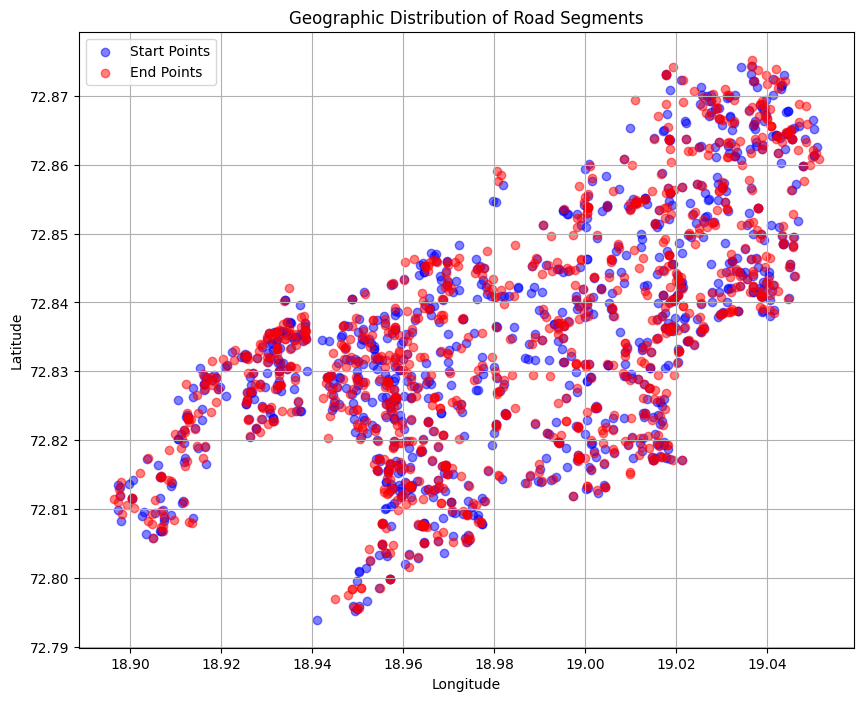

In [24]:
plt.figure(figsize=(10, 8))
plt.scatter(df_sorted["start_long"], df_sorted["start_lat"], color='blue', label="Start Points", alpha=0.5)
plt.scatter(df_sorted["end_long"], df_sorted["end_lat"], color='red', label="End Points", alpha=0.5)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Distribution of Road Segments")
plt.legend()
plt.grid()
plt.show()

In [25]:
import urllib.parse

def generate_google_maps_urls(segments, max_waypoints=20):
    """
    Creates one or more Google Maps directions URLs from a list of road segments.
    Google Maps allows up to `max_waypoints` (default 10) in a single request.
    """
    base_url = "https://www.google.com/maps/dir/"
    urls = []

    # Process segments in chunks of `max_waypoints`
    for i in range(0, len(segments), max_waypoints - 1):  # -1 because the last point is end
        waypoint_chunk = segments[i:i + max_waypoints - 1]
        
        waypoints = [f"{seg['start_long']},{seg['start_lat']}" for seg in waypoint_chunk]

        # Append last segment's end point
        last_segment = waypoint_chunk[-1]
        waypoints.append(f"{last_segment['end_long']},{last_segment['end_lat']}")

        # Encode waypoints into URL
        url = base_url + "/".join(waypoints)
        urls.append(urllib.parse.quote(url, safe=':/,'))  # Ensure URL encoding

    return urls  # Returns a list of URLs if multiple needed


In [26]:
itinerary_links = []
for itinerary in itineraries:
    itinerary_id = itinerary["itinerary_id"]
    urls = generate_google_maps_urls(itinerary["segments"])

    for idx, url in enumerate(urls):
        itinerary_links.append({"itinerary_id": itinerary_id, "part": idx + 1, "google_maps_url": url})
        print(f"Itinerary {itinerary_id} Part {idx + 1}: {url}")

# Convert to DataFrame
df_maps = pd.DataFrame(itinerary_links)

# Save the links
df_maps.to_csv("../out/google_maps_itineraries-mumbai-city-osrm.csv", index=False)
print("✅ Saved Google Maps itinerary links to 'google_maps_itineraries-mumbai-city-osrm.csv'.")


Itinerary 1 Part 1: https://www.google.com/maps/dir/19.0255655,72.8397849/19.0245504,72.837647/19.0254134,72.8358579/19.0254641,72.8357626/19.0261985,72.8362797/19.0293133,72.837866/19.0297678,72.8382468/19.0304082,72.8384695/19.0303658,72.8385518/19.0312781,72.8400143/19.0295415,72.8415767/19.0315329,72.8420022/19.031514,72.8420862/19.0320796,72.8420472/19.0336313,72.8387896/19.0336434,72.8387007/19.0390818,72.8387464/19.0390538,72.8386577/19.0407347,72.8403301/19.0406862,72.8411159
Itinerary 1 Part 2: https://www.google.com/maps/dir/19.041516,72.8388655/19.0407873,72.8380551/19.0389857,72.8408593/19.0389945,72.8409717/19.0388149,72.8409813/19.0390408,72.8418244/19.0410823,72.8416345/19.0414555,72.8425923/19.0404701,72.8438742/19.0404259,72.8444869/19.0394396,72.84452214999999/19.0391306,72.8429386/19.039882,72.8427896/19.0384786,72.8421613/19.0370158,72.8422012/19.037038,72.8415119/19.037038,72.8415119/19.0370488,72.8438519/19.0352931,72.8443852/19.0370622,72.8445032
Itinerary 1 Part

In [27]:
# OSRM URL Template
OSRM_BASE_URL = "https://map.project-osrm.org/?z=15"

# Function to generate OSRM map URL for each itinerary
def generate_osrm_urls(df, max_waypoints=20):
    urls = []
    for itinerary_id, group in df.groupby("itinerary_id"):
        waypoints = group[["start_long", "start_lat"]].values.tolist()
        
        # OSRM supports max 20 waypoints, so split into chunks
        part = 1
        for i in range(0, len(waypoints), max_waypoints):
            chunk = waypoints[i:i+max_waypoints]
            center_lat, center_lon = chunk[0]  # Use first waypoint as map center
            loc_params = "&".join([f"loc={lat},{lon}" for lat, lon in chunk])
            url = f"{OSRM_BASE_URL}&center={center_lat},{center_lon}&{loc_params}&hl=en&alt=0&srv=1"
            urls.append({"itinerary_id": itinerary_id, "part": part, "osrm_maps_url": url})
            part += 1
    
    return urls

# Generate URLs
osrm_urls = generate_osrm_urls(df_itineraries, 100)

# Print results
for r in osrm_urls:
    print(f"Itinerary {r['itinerary_id']} Part {r['part']}: {r['osrm_maps_url']}")

Itinerary 1 Part 1: https://map.project-osrm.org/?z=15&center=19.0255655,72.8397849&loc=19.0255655,72.8397849&loc=19.0245504,72.837647&loc=19.0254134,72.8358579&loc=19.0254641,72.8357626&loc=19.0261985,72.8362797&loc=19.0293133,72.837866&loc=19.0297678,72.8382468&loc=19.0304082,72.8384695&loc=19.0303658,72.8385518&loc=19.0312781,72.8400143&loc=19.0295415,72.8415767&loc=19.0315329,72.8420022&loc=19.031514,72.8420862&loc=19.0320796,72.8420472&loc=19.0336313,72.8387896&loc=19.0336434,72.8387007&loc=19.0390818,72.8387464&loc=19.0390538,72.8386577&loc=19.0407347,72.8403301&loc=19.041516,72.8388655&loc=19.0407873,72.8380551&loc=19.0389857,72.8408593&loc=19.0389945,72.8409717&loc=19.0388149,72.8409813&loc=19.0390408,72.8418244&loc=19.0410823,72.8416345&loc=19.0414555,72.8425923&loc=19.0404701,72.8438742&loc=19.0404259,72.8444869&loc=19.0394396,72.84452214999999&loc=19.0391306,72.8429386&loc=19.039882,72.8427896&loc=19.0384786,72.8421613&loc=19.0370158,72.8422012&loc=19.037038,72.8415119&loc=1

In [28]:
# Convert to DataFrame
df_maps = pd.DataFrame(osrm_urls)

# Save the links
df_maps.to_csv("../out/osrm_maps_itineraries-mumbai-city-osrm.csv", index=False)
print("✅ Saved OSRM Maps itinerary links to 'osrm_maps_itineraries-mumbai-city-osrm.csv'.")

✅ Saved OSRM Maps itinerary links to 'osrm_maps_itineraries-mumbai-city-osrm.csv'.
